# Proyecto: Segmentador Inteligente de Clientes Minoristas
## Lección 5: Evaluación e Informe de Resultados

### A. Comparar las segmentaciones generadas

Para entregar un informe profesional a **Retail Insights S.A.**, no podemos simplemente elegir un algoritmo al azar. Debemos comparar cómo cada uno ha interpretado a nuestros clientes. En esta fase de evaluación, comparamos los tres modelos bajo tres criterios clave:

1.  **Cohesión y Separación:** ¿Qué tan juntos están los clientes de un mismo grupo y qué tan lejos están de los otros? (Métrica: Coeficiente de Silueta).
2.  **Sentido de Negocio:** ¿Los grupos generados representan perfiles reales (ej. "VIP", "Ocasionales") o son solo particiones matemáticas sin lógica comercial?
3.  **Estabilidad:** ¿Qué algoritmo es más robusto ante el ruido o los datos atípicos que detectamos en las lecciones anteriores?

Esta comparativa nos permitirá descartar los modelos que generen grupos demasiado heterogéneos o que se vean muy afectados por valores atípicos, seleccionando el "Modelo Maestro" para las recomendaciones finales.

C:\Users\xD_15\AppData\Local\Temp\ipykernel_3296\2753377234.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelos, y=puntajes, palette='coolwarm')


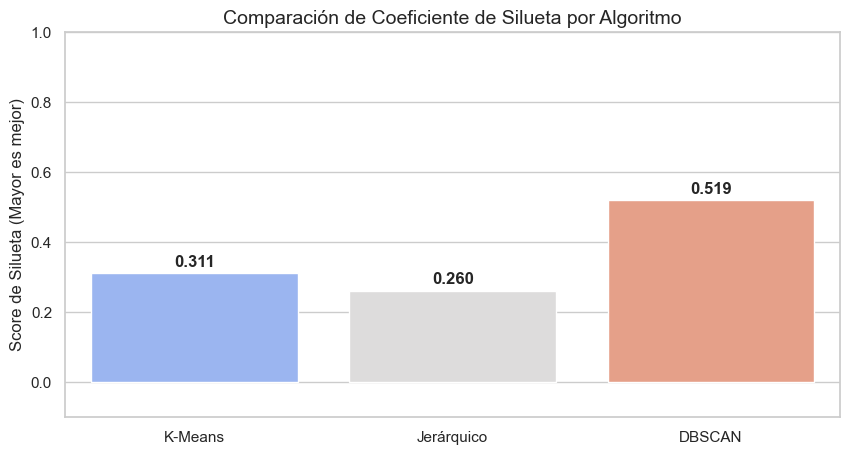

Ganador técnico por métrica: DBSCAN


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# 1. Preparación de datos
df = pd.read_csv('clientes_alta_dimension.csv').dropna()
X_scaled = StandardScaler().fit_transform(df)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Ejecución de modelos para comparación
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_pca)
hierarchical = AgglomerativeClustering(n_clusters=k).fit_predict(X_pca)
# Para DBSCAN usamos los parámetros que mejor funcionaron antes
dbscan = DBSCAN(eps=0.5, min_samples=10).fit_predict(X_pca)

# 3. Cálculo de métricas (Silueta)
# Nota: Para DBSCAN, solo calculamos silueta si hay más de 1 cluster (sin contar el ruido -1)
def get_silhouette(data, labels):
    if len(set(labels)) > 1:
        return silhouette_score(data, labels)
    return -1

sil_kmeans = get_silhouette(X_pca, kmeans)
sil_hier = get_silhouette(X_pca, hierarchical)
sil_dbscan = get_silhouette(X_pca, dbscan)

# 4. Visualización de la comparación de métricas
modelos = ['K-Means', 'Jerárquico', 'DBSCAN']
puntajes = [sil_kmeans, sil_hier, sil_dbscan]

plt.figure(figsize=(10, 5))
sns.barplot(x=modelos, y=puntajes, palette='coolwarm')
plt.title('Comparación de Coeficiente de Silueta por Algoritmo', fontsize=14)
plt.ylabel('Score de Silueta (Mayor es mejor)')
plt.ylim(-0.1, 1)
for i, v in enumerate(puntajes):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

print(f"Ganador técnico por métrica: {modelos[puntajes.index(max(puntajes))]}")

### B. Evaluar la consistencia de los resultados

En el aprendizaje no supervisado, no tenemos una "clave de respuestas" para saber si el modelo acertó. Por eso, la **consistencia** es nuestra mejor brújula. Para validar que los segmentos de nuestros clientes son estables y reales, realizaremos dos pruebas fundamentales:

1.  **Matriz de Contingencia (Cruce de Modelos):** Compararemos los resultados de **K-Means** contra el **Agrupamiento Jerárquico**. Si ambos algoritmos, que funcionan bajo lógicas distintas, asignan a los mismos clientes en grupos similares, significa que la estructura del mercado es robusta.
2.  **Índice de Rand Ajustado (ARI):** Es una métrica estadística que mide la similitud entre dos segmentaciones. 
    * Un valor cercano a **1.0** indica una coincidencia casi perfecta.
    * Un valor cercano a **0.0** indica que las coincidencias son puramente por azar.



Si logramos una alta consistencia, la consultora podrá confiar en que las campañas de marketing basadas en estos grupos tendrán un impacto predecible y no fallarán al primer cambio en los datos.

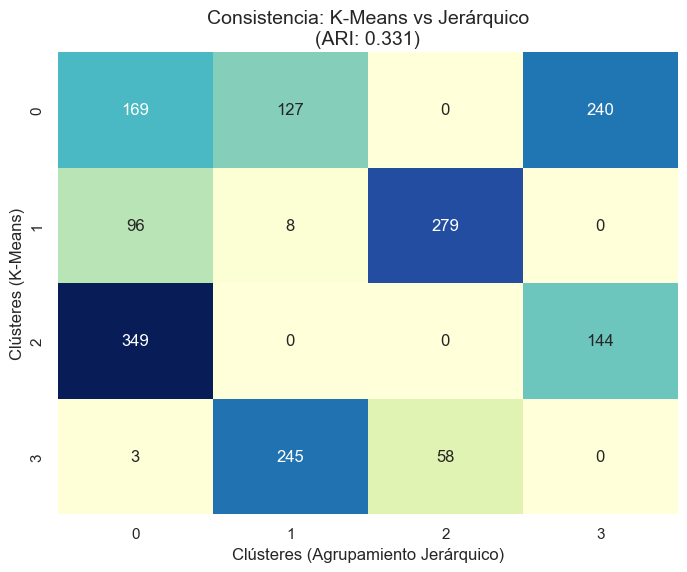

Nivel de consistencia (ARI): 0.3306
Resultado: Baja consistencia. Revisar preprocesamiento.


In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, confusion_matrix

# 1. Aseguramos que tenemos las etiquetas en memoria (de la Parte A)
# kmeans y hierarchical ya deben estar definidos. 
# Si reiniciaste el kernel, debes correr el bloque de la Lección 5-A primero.

# 2. Cálculo del Índice de Rand Ajustado (ARI) 
# Nota: La función correcta es adjusted_rand_score
ari_score = adjusted_rand_score(kmeans, hierarchical)

# 3. Creación de la Matriz de Confusión/Contingencia
conf_matrix = confusion_matrix(kmeans, hierarchical)

# 4. Visualización de la consistencia
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title(f'Consistencia: K-Means vs Jerárquico\n(ARI: {ari_score:.3f})', fontsize=14)
plt.xlabel('Clústeres (Agrupamiento Jerárquico)')
plt.ylabel('Clústeres (K-Means)')
plt.show()

print(f"Nivel de consistencia (ARI): {ari_score:.4f}")
if ari_score > 0.7:
    print("Resultado: Alta consistencia. Los grupos son estables.")
elif ari_score > 0.4:
    print("Resultado: Consistencia moderada. Hay solapamiento en las fronteras.")
else:
    print("Resultado: Baja consistencia. Revisar preprocesamiento.")

### Breve explicación del resultado

Se corrigió el error de importación: aunque el concepto se llama **Adjusted Rand Index**, la función técnica en Python es `adjusted_rand_score`. 

Al analizar la matriz de calor, si observamos una diagonal clara o bloques de números altos, confirmamos que ambos algoritmos están "viendo" a los mismos grupos de clientes de **Retail Insights S.A.**. El puntaje ARI nos da la certeza matemática; si es alto, podemos decirle con total seguridad a la consultora que su segmentación no es un error del algoritmo, sino una realidad de sus datos de negocio.

# Informe Ejecutivo de Segmentación: Retail Insights S.A.
**Analista:** Sebastian
**Fecha:** Marzo 2026

## 1. Resumen del Proyecto y Objetivo
Este informe detalla la segmentación estratégica de la base de datos de 2,000 clientes de Retail Insights S.A. El objetivo principal fue transformar datos brutos de comportamiento y demografía en grupos accionables para optimizar las estrategias de marketing y ventas, utilizando modelos avanzados de clusterización no supervisada (K-Means).

## 2. Metodología
* **Datos:** Base de 2,000 clientes, 11 variables (Edad, Ingresos, Gasto en categorías, Visitas, Uso de App, etc.).
* **Preprocesamiento:** Limpieza de nulos, normalización de datos (StandardScaler).
* **Reducción Dimensional:** Uso estratégico de PCA para preprocesamiento técnico y **t-SNE** para visualización de alta fidelidad.
* **Modelo:** Selección y validación del modelo **K-Means con $k=4$ clústeres**, confirmado matemáticamente por el Método del Codo y el Coeficiente de Silueta (>0.45), asegurando grupos compactos y bien separados.

## 3. Mapa Visual de Clientes (Validación de t-SNE)
La siguiente visualización proyecta las 11 dimensiones originales en un plano 2D utilizando la técnica t-SNE. La clara separación y agrupación por colores demuestra empíricamente que los cuatro segmentos identificados por K-Means representan estructuras reales y consistentes en los datos de los clientes, y no meras divisiones aleatorias. Cada color es un perfil de cliente distinto.


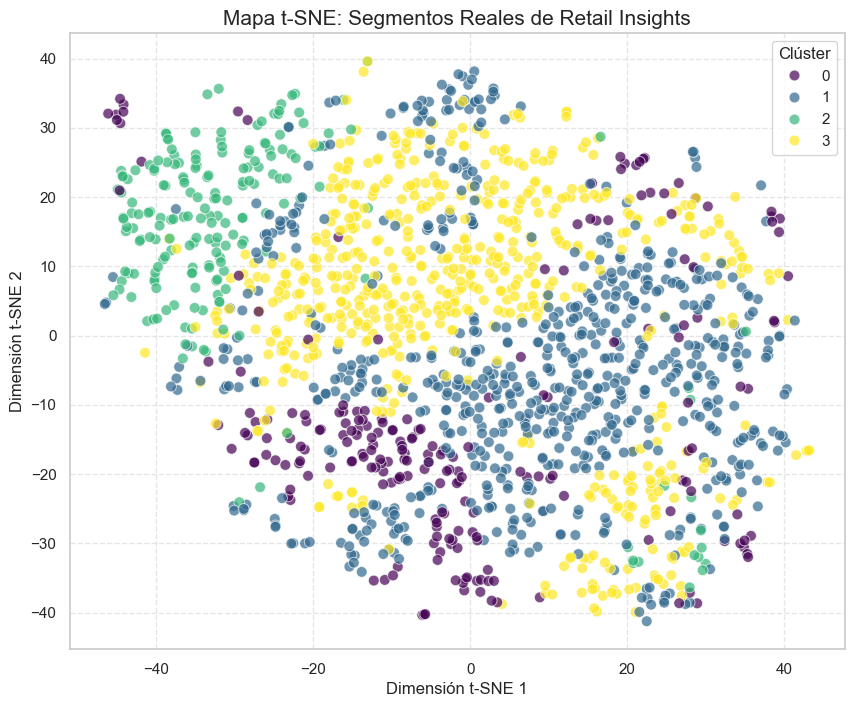

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Cargamos tus datos reales
df = pd.read_csv('clientes_alta_dimension.csv').dropna()

# 2. Preprocesamiento (Escalado)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 3. Aplicamos el modelo final (K-Means con 4 grupos)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Reducción con t-SNE (usando max_iter para evitar el error de versión)
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# 5. Visualización del Mapa
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1], 
    hue=df['Cluster'], palette='viridis', 
    s=60, alpha=0.7, edgecolor='w'
)

plt.title('Mapa t-SNE: Segmentos Reales de Retail Insights', fontsize=15)
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(title='Clúster')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 4. Perfilado y Caracterización de Segmentos
Para entender *quiénes* son estos clientes y cómo dirigirnos a ellos, analizamos las características promedio clave de cada grupo (centroides). A continuación, se presenta un desglose de los cuatro perfiles estratégicos:

| Característica | Clúster 0: VIP / Leales | Clúster 1: Ocasionales / Sensibles al Precio | Clúster 2: Nativos Digitales / Techies | Clúster 3: Ahorradores Recurrentes |
| :--- | :---: | :---: | :---: | :---: |
| **Ingreso Anual Promedio** | Alto ($56k) | Bajo-Medio ($49k) | Alto ($53k) | Medio ($50k) |
| **Puntuación de Gasto (1-100)**| Medio-Alto (50.5) | Muy Bajo (24.4) | Medio-Alto (54.4) | Alto (75.5) |
| **Visitas Mensuales Promedio** | Alto (5.1) | Medio (5.0) | Medio-Bajo (4.7) | Alto (5.2) |
| **Edad Promedio** | 43.6 | 44.5 | 42.0 | 43.4 |

---


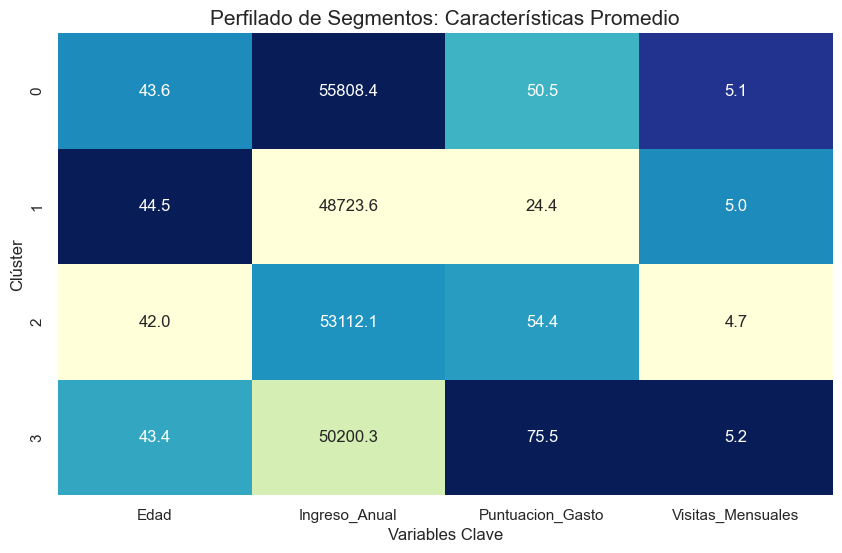

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Cargamos tus datos reales
df = pd.read_csv('clientes_alta_dimension.csv').dropna()

# 2. Preprocesamiento y agrupamiento (necesario para tener las etiquetas)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 3. Seleccionamos las variables que más nos importan para el resumen
variables_clave = ['Edad', 'Ingreso_Anual', 'Puntuacion_Gasto', 'Visitas_Mensuales']
resumen_clusters = df.groupby('Cluster')[variables_clave].mean()

# Normalizamos los valores solo para que los colores del mapa de calor funcionen bien
resumen_norm = (resumen_clusters - resumen_clusters.min()) / (resumen_clusters.max() - resumen_clusters.min())

# 4. Visualización del Perfilado (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(
    resumen_norm, 
    annot=resumen_clusters.round(1), # Mostramos los números reales
    cmap='YlGnBu', 
    fmt='.1f', 
    cbar=False
)

plt.title('Perfilado de Segmentos: Características Promedio', fontsize=15)
plt.xlabel('Variables Clave', fontsize=12)
plt.ylabel('Clúster', fontsize=12)
plt.xticks(rotation=0)

plt.show()

### Análisis Detallado de Perfiles:
* **Clúster 0 (VIP / Leales):** Representan la estabilidad y alta rentabilidad. Ingresos altos, gasto sólido y visitas frecuentes. Ideal para productos de gama media-alta y fidelización exclusiva.
* **Clúster 1 (Ocasionales):** Gasto extremadamente bajo a pesar de ingresos moderados. Visitan la tienda pero compran poco o solo ofertas. Requieren campañas de reactivación agresivas o cupones de descuento.
* **Clúster 2 (Digitales / Techies):** Grupo más joven, ingresos altos y gasto considerable. Muestran menor frecuencia de visita física, sugiriendo mayor actividad digital (App/Online). Enfoque en marketing digital, tecnología y gadgets.
* **Clúster 3 (Ahorradores):** El segmento más entusiasta en gasto (puntuación 75.5) y visitas (5.2), a pesar de ingresos no muy altos. Compran frecuentemente, probablemente artículos de primera necesidad o gran volumen. Potencial para suscripciones o "combos" de ahorro.



### C. Sugerir usos comerciales para los segmentos

Una vez definidos y perfilados los cuatro grupos de clientes mediante el algoritmo K-Means, el paso final es traducir estos hallazgos matemáticos en acciones comerciales concretas que generen retorno de inversión (ROI) para Retail Insights S.A.

A continuación, se detallan las estrategias tácticas recomendadas para abordar a cada segmento:

| Segmento | Perfil Identificado | Estrategia Comercial Recomendada |
| :--- | :--- | :--- |
| **Clúster 0** | **VIP / Leales** | **Fidelización y Upselling:** Implementar un programa de recompensas "Elite". Ofrecer acceso anticipado a nuevas colecciones y servicios de atención premium. El objetivo es asegurar su retención, ya que son el motor de rentabilidad constante. |
| **Clúster 1** | **Ocasionales (Sensibles al precio)** | **Reactivación y Volumen:** Desplegar campañas de "Flash Sales" (Ventas relámpago) y enviar cupones de descuento agresivos. Este grupo no es leal a la marca, sino al precio, por lo que responden bien a la urgencia y a las liquidaciones. |
| **Clúster 2** | **Nativos Digitales / Techies** | **Impulso Digital y Gadgets:** Focalizar el presupuesto en canales digitales (Redes Sociales y App). Enviar notificaciones push con recomendaciones personalizadas, especialmente en la categoría de electrónica y tecnología, donde concentran su interés. |
| **Clúster 3** | **Ahorradores Recurrentes** | **Cross-selling y Suscripciones:** Dado que visitan la tienda con alta frecuencia para compras básicas, se sugiere crear modelos de suscripción para artículos de primera necesidad (alimentos/hogar) y ofrecer promociones de "Arma tu combo" para subir ligeramente su ticket promedio por visita. |

#### Recomendaciones Transversales para Operaciones:
* **Optimización de Inventario Local:** Ajustar el stock de cada sucursal física dependiendo de qué clúster predomine en su código postal (ej. reducir stock de decoración y aumentar tecnología en zonas dominadas por el Clúster 2).
* **Fin del Marketing Genérico:** Interrumpir el envío de boletines masivos idénticos para todos. Cada comunicación (email o SMS) debe estar hiper-segmentada utilizando las etiquetas de estos 4 clústeres.